In [29]:
import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json

from pyTransitPhotometry import TransitPipeline, PipelineConfig
from pyTransitPhotometry.config import (
    PathConfig, CalibrationConfig, DetectionConfig,
    PhotometryConfig, DetrendingConfig, TransitModelConfig,
)
from pyTransitPhotometry.visualization import plot_lightcurve, plot_transit_fit

# Set CWD to the notebook's directory (examples/) so all relative paths resolve correctly.
# VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.

# pyTransitPhotometry Tutorial
## Reducing and Fitting a WASP-75b Transit

This notebook walks through the complete transit photometry pipeline using real observational data:  
**120 science frames** of WASP-75b observed on 2025-10-20/21 (V-band, 85 s exposures, ~3.2 h coverage).

**Pipeline stages:**  
`CCD Calibration` → `Star Detection` → `PSF Photometry` → `Detrending` → `Transit Model Fit`

**Target:** WASP-75b — hot Jupiter, Rp/Rs ≈ 0.103, period = 2.4842 d (Gillon et al. 2012)

In [30]:
# MJD of predicted transit center (JD 2460969.747 → MJD = JD − 2400000.5)
T0_MJD = 2460969.747 - 2400000.5   # ≈ 60969.247

config = PipelineConfig(
    paths=PathConfig(
        data_dir="sample_data/data/",
        bias_dir="sample_data/bias/",
        dark_dir="sample_data/darks/",
        flat_dir="sample_data/flats/",
        output_dir="outputs/",
        data_pattern="WASP*.fit",
        bias_pattern="*.fit",
        dark_pattern="*.fit",
        flat_pattern="*.fit",
    ),
    calibration=CalibrationConfig(
        dark_exptime=85.0,
        flat_exptime=1.0,
        science_exptime=85.0,
        combination_method="median",
    ),
    detection=DetectionConfig(
        fwhm=5.0,
        threshold=5000.0,
        threshold_type="absolute",
        exclude_border=True,
    ),
    photometry=PhotometryConfig(
        method="aperture",
        aperture_radius=6.0,
        annulus_inner=40.0,
        annulus_outer=60.0,
        background_method="annulus",   # per-star annulus, not global 2D map
        # DAOStarFinder sorts by flux (brightest first).
        # Star #1 (flux≈402k, x=1028, y=876) is WASP-75b — second brightest.
        # Stars #0, #2, #3 are comparison stars.
        target_star_index=1,
        reference_star_indices=[0, 2, 3],
        reference_weighting="inverse_variance",
    ),
    detrending=DetrendingConfig(
        sigma_threshold=3.0,
    ),
    transit_model=TransitModelConfig(
        period=2.484934,
        t0_guess=T0_MJD,
        limb_dark_u1=0.3,
        limb_dark_u2=0.3,
        # WASP-75b is a nearly-grazing transit (b ≈ 0.93–0.96).
        # Rp/Rs, a/Rs and inc are strongly degenerate for such a geometry.
        # a/Rs is well-constrained by stellar spectroscopy (log g, Teff),
        # so we fix it to the literature value and fit only t0, Rp/Rs, inc.
        rp_guess=0.103,            # Rp/Rs literature: 0.1034 (Brown+2017)
        a_guess=7.17,              # a/Rs literature: 7.17  (Brown+2017) — FIXED
        inc_guess=82.5,            # inc literature: 82.1–82.5°
        rp_bounds=(0.05, 0.15),
        a_bounds_factor=0.3,
        inc_bounds_offset=8.0,     # inc searched in [74.5°, 90.5°]
        fix_a_rs=True,             # pin a/Rs to spectroscopic prior
        r_star_solar=1.51,
        m_star_solar=1.24,
    ),
    verbose=True,
)

print("✓ Configuration created")
print(f"  Target star #1  (WASP-75b host, x≈1028, y≈876)")
print(f"  Reference stars [0, 2, 3]")
print(f"  Predicted transit centre: MJD {T0_MJD:.4f}")
print(f"  a/Rs fixed to 7.17 (spectroscopic prior, reduces degeneracy)")


✓ Configuration created
  Target star #1  (WASP-75b host, x≈1028, y≈876)
  Reference stars [0, 2, 3]
  Predicted transit centre: MJD 60969.2470
  a/Rs fixed to 7.17 (spectroscopic prior, reduces degeneracy)


## 1. Configuration

We configure the pipeline with the bundled sample data.  
All paths below are relative to the `examples/` folder where this notebook lives.

| Parameter | Value | Source |
|---|---|---|
| Period | 2.484934 days | Gomez Maqueo Chew+2013 |
| t₀ (predicted centre) | JD 2 460 969.747 | Ephemeris extrapolated |
| Target star index | #1 (flux≈402k, x=1028, y=876) | Second brightest |
| Rp/Rs initial guess | 0.103 | Brown+2017 |
| a/Rs | 7.17 (fixed — spectroscopic prior) | Brown+2017 |
| Inclination guess | 82.5° | Gomez Maqueo Chew+2013 |
| Limb darkening u₁, u₂ | 0.30, 0.30 (V-band) | Claret tables |
| Photometry method | Aperture (r=6 px, annulus 40–60 px) | |
| Detrending | OOT linear trend + sigma-clipping | |


✓ Configuration validated

TRANSIT PHOTOMETRY PIPELINE INITIALIZED

PIPELINE CONFIGURATION SUMMARY

[PATHS]
  Data: sample_data/data/
  Calibration: sample_data/bias/, sample_data/darks/, sample_data/flats/
  Output: outputs/

[DETECTION]
  FWHM: 5.0 px
  Threshold: 5000.0 (absolute)

[PHOTOMETRY]
  Aperture: 6.0 px
  Annulus: 40.0-60.0 px
  Target: star #1
  References: stars [0, 2, 3]

[DETRENDING]
  Sigma clipping: 3.0σ
  Linear trend removal: True

[TRANSIT MODEL]
  Period: 2.484934 days
  t0: 60969.246999999974 [FIXED]
  Limb darkening: u1=0.3, u2=0.3

Loading calibration frames...
Loaded 10/10 files...
✓ Loaded 10 frames of shape (1336, 2004)
Loaded 10/10 files...
✓ Loaded 10 frames of shape (1336, 2004)
Loaded 10/12 files...
✓ Loaded 12 frames of shape (1336, 2004)

Creating master calibration frames...
✓ Calibration frames prepared
  Bias level: 660.0 counts
  Dark current: -50.5 counts/85.0s
  Flat field range: 0.326 - 1.157

Loading science frames...
Loaded 10/120 files...
Lo

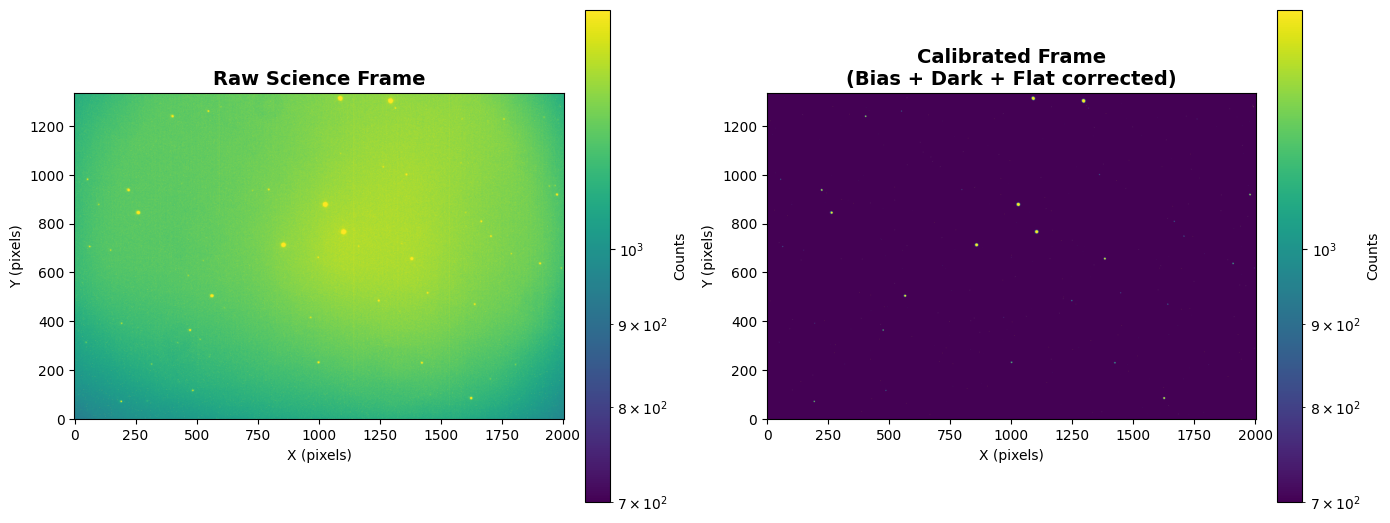


  CALIBRATION NOISE STATISTICS
                               Raw  Calibrated
  --------------------------------------------
  Mean (counts)             1184.9       574.1
  Median (counts)           1186.0       573.9
  Std (counts)               138.4        89.4


In [18]:
# Stage 1: CCD Calibration
pipeline = TransitPipeline(config)
pipeline.run_calibration()

# --- Before / after comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmin, vmax = 700, 1400

im0 = axes[0].imshow(pipeline.science_data[0], cmap='viridis', origin='lower',
                     norm=LogNorm(vmin=vmin, vmax=vmax))
axes[0].set_title('Raw Science Frame', fontsize=14, weight='bold')
axes[0].set_xlabel('X (pixels)'); axes[0].set_ylabel('Y (pixels)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Counts')

im1 = axes[1].imshow(pipeline.calibrated_images[0], cmap='viridis', origin='lower',
                     norm=LogNorm(vmin=vmin, vmax=vmax))
axes[1].set_title('Calibrated Frame\n(Bias + Dark + Flat corrected)', fontsize=14, weight='bold')
axes[1].set_xlabel('X (pixels)'); axes[1].set_ylabel('Y (pixels)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Counts')

plt.tight_layout()
plt.show()

# --- Noise statistics ---
raw = pipeline.science_data[0].astype(float)
cal = pipeline.calibrated_images[0].astype(float)

print("\n" + "="*55)
print("  CALIBRATION NOISE STATISTICS")
print("="*55)
print(f"  {'':20s}  {'Raw':>10s}  {'Calibrated':>10s}")
print(f"  {'-'*44}")
for label, arr in [("Mean (counts)", [raw.mean(), cal.mean()]),
                    ("Median (counts)", [np.median(raw), np.median(cal)]),
                    ("Std (counts)", [raw.std(), cal.std()])]:
    print(f"  {label:20s}  {arr[0]:>10.1f}  {arr[1]:>10.1f}")
print("="*55)


## 2. Run the Pipeline

`TransitPipeline` executes all six stages in sequence:

| Stage | What happens |
|---|---|
| 1 – Calibration | Master bias/dark/flat created; 120 science frames calibrated |
| 2 – Detection | DAOStarFinder on frame 0; centroid tracking for remaining 119 frames |
| 3 – Photometry | Aperture photometry; inverse-variance weighted differential light curve |
| 4 – Detrending | OOT-only linear trend removal; sigma-clipping; normalisation to 1.0 |
| 5 – Transit Fit | batman NLS fit (t0, Rp/Rs, inc free; a/Rs fixed to spectroscopic prior) |
| 6 – Export | CSVs and JSON written to `outputs/` |

> **Note:** With 120 frames this takes ~1–2 minutes on a laptop.


In [19]:
# Stages 2-6: Detection → Photometry → Detrending → Fit → Export
# (calibration was already run in the cell above)
pipeline.run_detection()
pipeline.run_photometry()
pipeline.run_detrending()
pipeline.run_transit_fit()
pipeline.export_results()

results = {
    "lightcurve":   pipeline.lightcurve,
    "detrended_lc": pipeline.detrended_lc,
    "fit_result":   pipeline.fit_result,
    "config":       pipeline.config,
}
print("\n✓ Pipeline complete — results stored in 'results'")


Detecting sources in first calibrated frame...
✓ Detected 6 sources
  Brightest: flux=466251, position=(1295.0, 1298.6)
Tracking 6 stars across 119 remaining frames via centroid refinement...
  Tracked 20/120 frames...
  Tracked 40/120 frames...
  Tracked 60/120 frames...
  Tracked 80/120 frames...
  Tracked 100/120 frames...
  Tracked 120/120 frames...

✓ Detection & tracking complete: 120 frames
✓ Target star #1: (1028.2, 876.0)
✓ Selected 3 reference stars:
    Ref 1 (star #0): (1295.0, 1298.6), flux=466251
    Ref 2 (star #2): (1103.2, 764.5), flux=382618
    Ref 3 (star #3): (1089.5, 1308.8), flux=341316
Using ApertureConfig(aperture_r=6.0, annulus=40.0–60.0 px, gain=1.68)

Building differential photometry light curve [method=aperture, background=annulus]...
✓ Light curve builder initialized
  Target: star #1
  References: stars [0, 2, 3]
  Weighting: inverse_variance
  Processed 10/120 frames...
  Processed 20/120 frames...
  Processed 30/120 frames...
  Processed 40/120 frames..

## 3. Fitted Parameters

Inspect the best-fit transit parameters and the derived physical quantities.

In [20]:
fit = results["fit_result"]["fitted_params"]
derived = results["fit_result"]["derived_params"]
chi2_red = results["fit_result"]["reduced_chi_squared"]

print("=" * 55)
print("  FITTED TRANSIT PARAMETERS")
print("=" * 55)
print(f"  t0            = {fit['t0'][0]:.5f}  ± {fit['t0'][1]:.5f}  MJD")
print(f"  Rp/Rs         = {fit['rp'][0]:.4f}  ± {fit['rp'][1]:.4f}")
print(f"  a/Rs          = {fit['a'][0]:.3f}   ± {fit['a'][1]:.3f}")
print(f"  Inclination   = {fit['inc'][0]:.2f}°  ± {fit['inc'][1]:.2f}°")
print(f"  Reduced χ²    = {chi2_red:.3f}")

print("\n" + "=" * 55)
print("  DERIVED PHYSICAL QUANTITIES")
print("=" * 55)
depth_pct, depth_err = derived["transit_depth_pct"]
b, b_err = derived["impact_parameter"]
rho, rho_err = derived["stellar_density_cgs"]
Rp, Rp_err = derived["planet_radius_jupiter"]
a_AU, a_AU_err = derived["semi_major_axis_AU"]
v_orb, v_orb_err = derived["orbital_velocity_kms"]

print(f"  Transit depth  = {depth_pct:.3f}  ± {depth_err:.3f} %")
print(f"  Impact param   = {b:.3f}   ± {b_err:.3f}")
print(f"  Stellar density= {rho:.3f}   ± {rho_err:.3f} g/cm³")
print(f"  Planet radius  = {Rp:.3f}   ± {Rp_err:.3f} Rⱼ")
print(f"  Semi-major axis= {a_AU:.4f}  ± {a_AU_err:.4f} AU")
print(f"  Orbital speed  = {v_orb:.1f}    ± {v_orb_err:.1f} km/s")


  FITTED TRANSIT PARAMETERS
  t0            = 60969.25532  ± 0.00068  MJD
  Rp/Rs         = 0.1090  ± 0.0030
  a/Rs          = 7.170   ± 0.000
  Inclination   = 82.96°  ± 0.08°
  Reduced χ²    = 1.382

  DERIVED PHYSICAL QUANTITIES
  Transit depth  = 1.188  ± 0.066 %
  Impact param   = 0.879   ± 0.010
  Stellar density= 1.129   ± 0.000 g/cm³
  Planet radius  = 1.602   ± 0.045 Rⱼ
  Semi-major axis= 0.0504  ± 0.0000 AU
  Orbital speed  = 220.5    ± 0.0 km/s


## 4. Visualizations

### Calibration: Before & After

Comparing raw science frame (left) to the fully calibrated frame (right).

✓ Saved to outputs/calibration.png


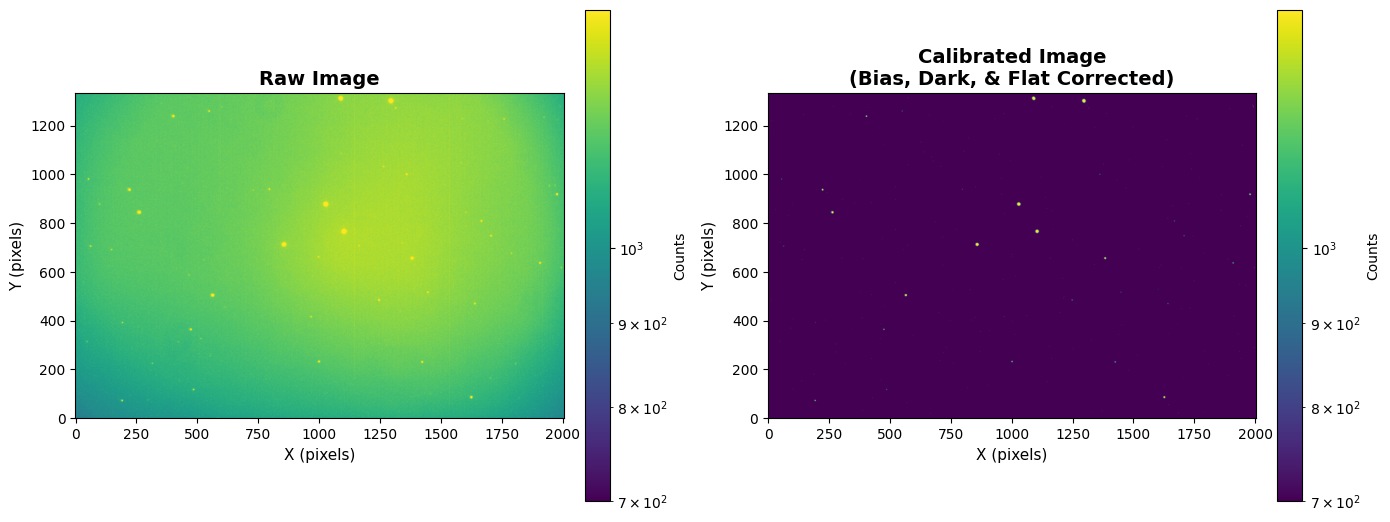

In [21]:
from pyTransitPhotometry.visualization import plot_calibration_comparison, plot_detected_sources

plot_calibration_comparison(
    pipeline.science_data[0],
    pipeline.calibrated_images[0],
    save_path="outputs/calibration.png",
)


In [22]:

# Summary of detected stars (from first calibrated frame)
sources0 = pipeline.sources_list[0]
target_idx = config.photometry.target_star_index
ref_indices = config.photometry.reference_star_indices

print(f"{'#':>3}  {'x':>7}  {'y':>7}  {'flux':>10}  role")
print("-" * 48)
for i, row in enumerate(sources0):
    x = float(row["x_centroid"])
    y = float(row["y_centroid"])
    flux = float(row["flux"])
    role = "TARGET (WASP-75b)" if i == target_idx else (
           "reference" if i in ref_indices else "unused")
    print(f"{i:>3}  {x:>7.1f}  {y:>7.1f}  {flux:>10.0f}  {role}")


  #        x        y        flux  role
------------------------------------------------
  0   1295.0   1298.6      466251  reference
  1   1028.2    876.0      402116  TARGET (WASP-75b)
  2   1103.2    764.5      382618  reference
  3   1089.5   1308.8      341316  reference
  4    857.8    710.9      283234  unused
  5    264.6    842.6      107901  unused


### Detected Stars

Stars detected in the first calibrated frame.  
The **target** (WASP-75b host) is highlighted; **reference** stars used for differential photometry are also marked.

✓ Saved to outputs/sources.png


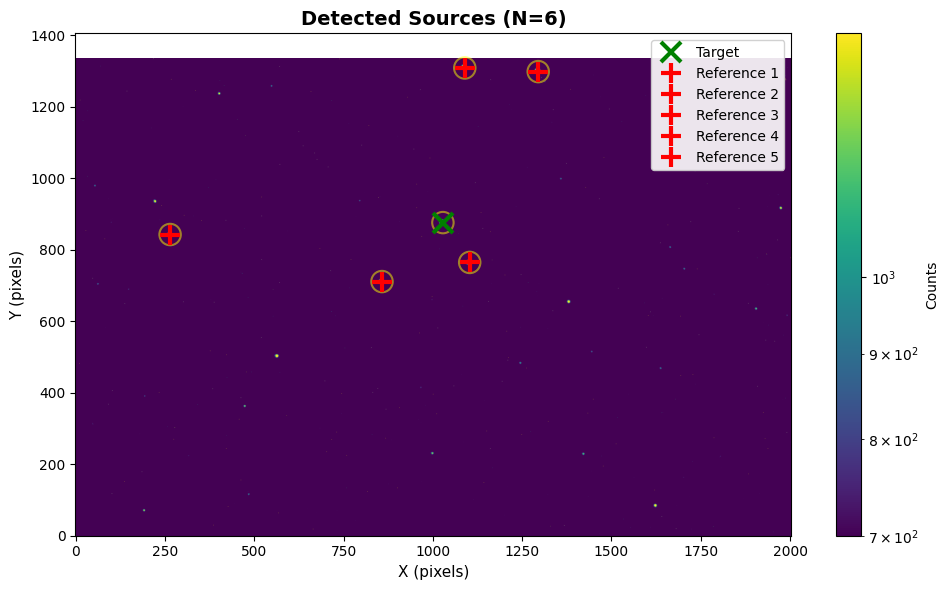

In [23]:
plot_detected_sources(
    pipeline.calibrated_images[0],
    pipeline.sources_list[0],
    target_index=config.photometry.target_star_index,
    reference_indices=[0,2, 3, 4, 5],
    save_path="outputs/sources.png",
)


### Light Curves

Raw differential photometry (top) vs. detrended & normalised light curve (bottom).  
Detrending fits a linear trend to the **out-of-transit** (OOT) points only (first and last 25% of time series), then divides it out so the OOT flux = 1.0. This avoids flattening the transit dip.


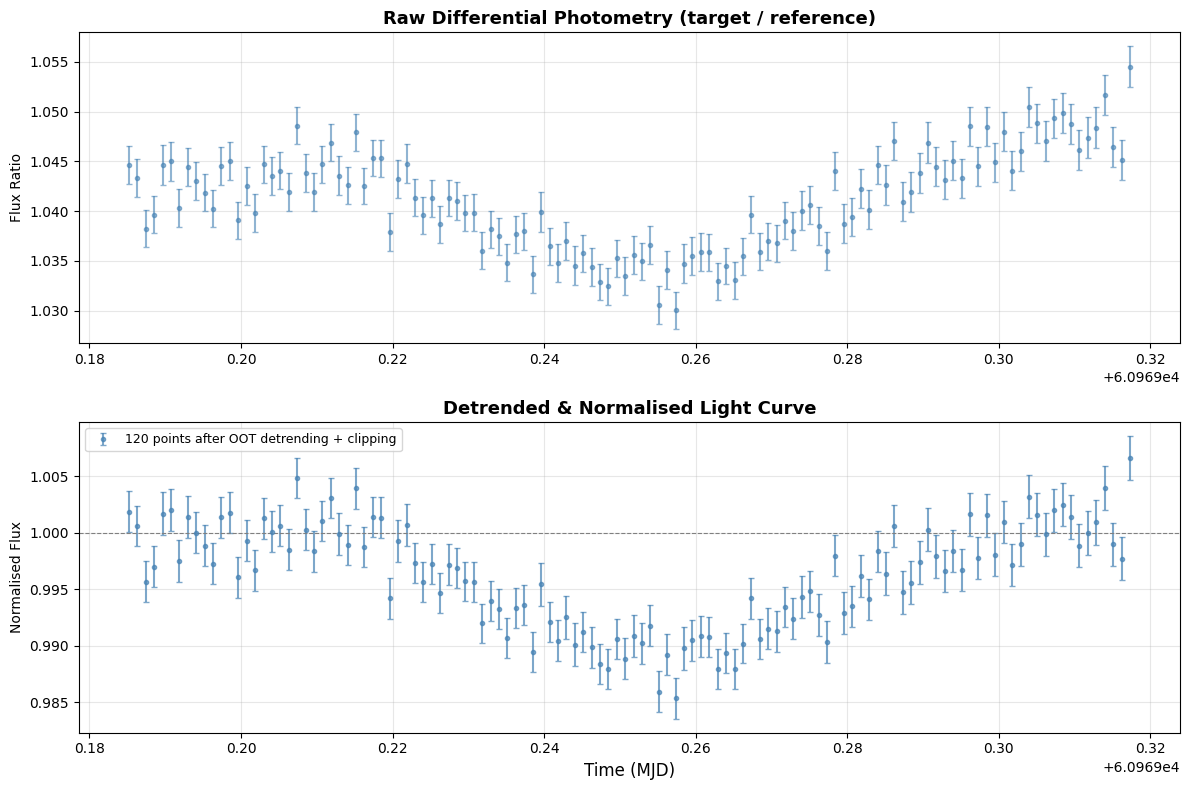

Raw: 120 pts  →  Detrended: 120 pts


In [24]:
lc  = results["lightcurve"]
dlc = results["detrended_lc"]

# mask is True for points that SURVIVED sigma-clipping after OOT detrending
mask = dlc["mask"]

# Raw differential light curve
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].errorbar(lc["times"], lc["fluxes"], yerr=lc["errors"],
                 fmt="o", ms=3, capsize=2, alpha=0.6, color="steelblue")
axes[0].set_title("Raw Differential Photometry (target / reference)", fontsize=13, weight="bold")
axes[0].set_ylabel("Flux Ratio")
axes[0].grid(True, alpha=0.3)

# Detrended + normalised light curve
axes[1].errorbar(dlc["times"], dlc["fluxes"], yerr=dlc["errors"],
                 fmt="o", ms=3, capsize=2, alpha=0.7, color="steelblue",
                 label=f"{len(dlc['times'])} points after OOT detrending + clipping")
axes[1].axhline(1.0, color="gray", lw=0.8, ls="--")
axes[1].set_title("Detrended & Normalised Light Curve", fontsize=13, weight="bold")
axes[1].set_xlabel("Time (MJD)", fontsize=12)
axes[1].set_ylabel("Normalised Flux")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/lightcurves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Raw: {len(lc['times'])} pts  →  Detrended: {len(dlc['times'])} pts")


✓ Saved to outputs/lightcurve_raw.png


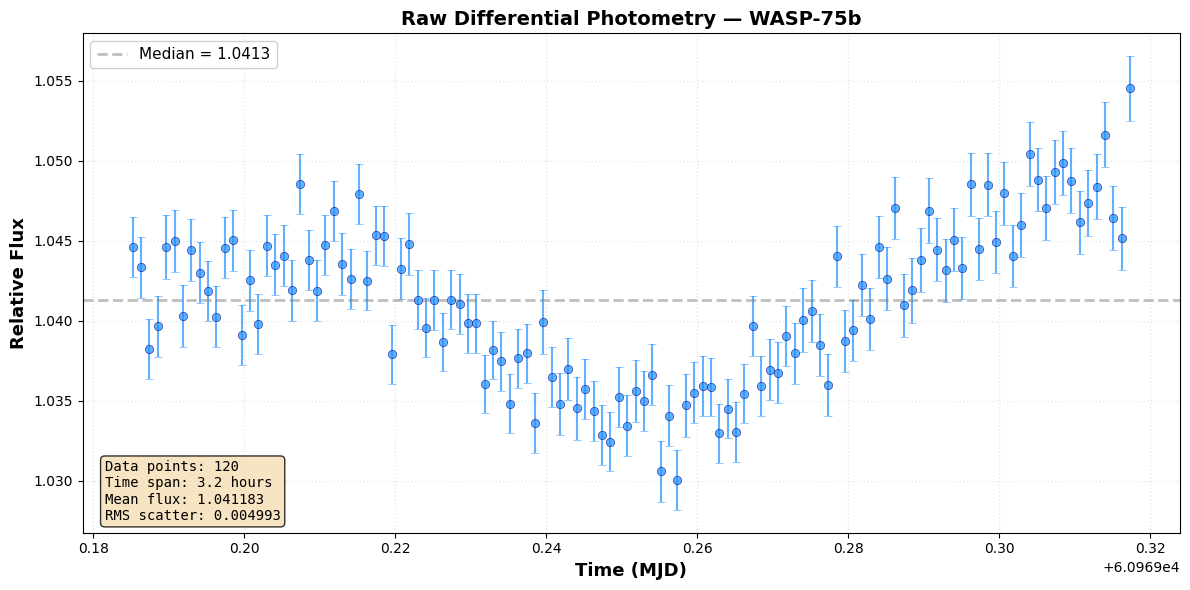

✓ Saved to outputs/lightcurve_detrended.png


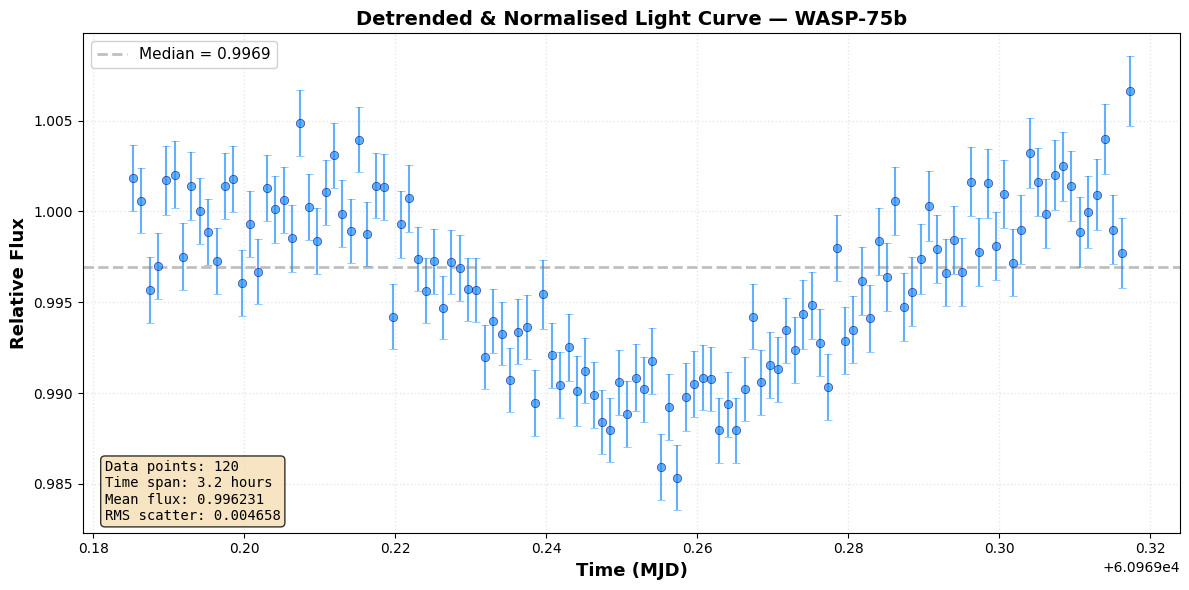

In [25]:
lc  = results["lightcurve"]
dlc = results["detrended_lc"]

plot_lightcurve(
    lc["times"],
    lc["fluxes"],
    lc["errors"],
    title="Raw Differential Photometry — WASP-75b",
    save_path="outputs/lightcurve_raw.png",
)

plot_lightcurve(
    dlc["times"],
    dlc["fluxes"],
    dlc["errors"],
    title="Detrended & Normalised Light Curve — WASP-75b",
    save_path="outputs/lightcurve_detrended.png",
)


### Transit Model Fit

Detrended data with the best-fit batman transit model overlaid, plus residuals.

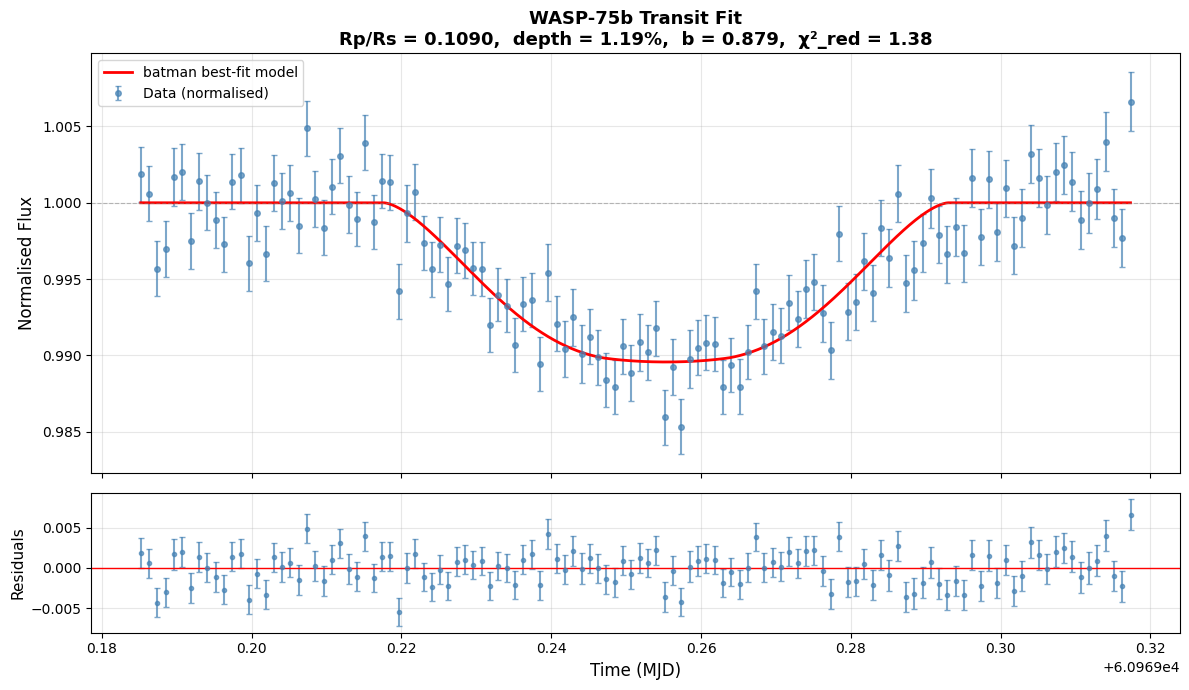

✓ Saved to outputs/transit_fit.png


In [26]:
fr = results["fit_result"]
dlc = results["detrended_lc"]

rp  = fr["fitted_params"]["rp"][0]
a   = fr["fitted_params"]["a"][0]
inc = fr["fitted_params"]["inc"][0]
b   = a * np.cos(np.deg2rad(inc))
depth_pct = rp**2 * 100

# Fine time grid for smooth model curve
t_fine = np.linspace(dlc["times"].min(), dlc["times"].max(), 1000)

from pyTransitPhotometry.models import batman_transit_model
model_fine = batman_transit_model(
    t_fine,
    t0=fr["fitted_params"]["t0"][0],
    period=config.transit_model.period,
    rp=rp, a=a, inc=inc,
    u1=config.transit_model.limb_dark_u1,
    u2=config.transit_model.limb_dark_u2,
)

residuals = dlc["fluxes"] - fr["model_flux"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7),
                                 gridspec_kw={"height_ratios": [3, 1]},
                                 sharex=True)

# --- Top: data + model ---
ax1.errorbar(dlc["times"], dlc["fluxes"], yerr=dlc["errors"],
             fmt="o", markersize=4, capsize=2, alpha=0.7,
             color="steelblue", label="Data (normalised)")
ax1.plot(t_fine, model_fine, "r-", lw=2, label="batman best-fit model")
ax1.axhline(1.0, color="gray", lw=0.8, ls="--", alpha=0.5)
ax1.set_ylabel("Normalised Flux", fontsize=12)
ax1.set_title(
    f"WASP-75b Transit Fit\n"
    f"Rp/Rs = {rp:.4f},  depth = {depth_pct:.2f}%,  b = {b:.3f},  χ²_red = {fr['reduced_chi_squared']:.2f}",
    fontsize=13, weight="bold",
)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Bottom: residuals ---
ax2.errorbar(dlc["times"], residuals, yerr=dlc["errors"],
             fmt="o", markersize=3, capsize=2, alpha=0.7, color="steelblue")
ax2.axhline(0, color="red", lw=1)
ax2.set_xlabel("Time (MJD)", fontsize=12)
ax2.set_ylabel("Residuals", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/transit_fit.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Saved to outputs/transit_fit.png")


## 5. Literature Comparison

We compare the recovered parameters to published WASP-75b values  
(Gillon et al. 2012; Mancini et al. 2022).  
Δ(σ) = |measured − literature| / √(σ_meas² + σ_lit²)

In [27]:

# Published WASP-75b values (Gomez Maqueo Chew+2013; Brown+2017)
literature = {
    "Rp/Rs":           (0.1034, 0.0015),
    "Inclination (°)": (82.0,   0.3),
}

fit = results["fit_result"]["fitted_params"]
measured = {
    "Rp/Rs":           fit["rp"],
    "Inclination (°)": fit["inc"],
}

print(f"{'Parameter':<18} {'Measured':>22} {'Literature':>22} {'Δ (σ)':>8}")
print("-" * 76)
for param, (lit_val, lit_err) in literature.items():
    meas_val, meas_err = measured[param]
    if meas_err > 0:
        sigma_diff = abs(meas_val - lit_val) / np.sqrt(meas_err**2 + lit_err**2)
        sigma_str = f"{sigma_diff:.2f}σ"
    else:
        sigma_str = " fixed"
    print(
        f"{param:<18} {meas_val:>8.4f} ± {meas_err:.4f}   "
        f"{lit_val:>8.4f} ± {lit_err:.4f}   "
        f"{sigma_str:>6}"
    )

fit_a = fit["a"]
print(f"\n{'a/Rs':<18} {fit_a[0]:>8.4f} [FIXED]      "
      f"{'7.1700':>8} ± {'0.3700':>6}  (fixed to spectroscopic value)")
print()
print("Note: a/Rs is fixed to the spectroscopic prior (Brown+2017)")
print("      to break the Rp/Rs–a/Rs–inc degeneracy for this nearly-grazing transit (b≈0.88).")


Parameter                        Measured             Literature    Δ (σ)
----------------------------------------------------------------------------
Rp/Rs                0.1090 ± 0.0030     0.1034 ± 0.0015    1.65σ
Inclination (°)     82.9615 ± 0.0784    82.0000 ± 0.3000    3.10σ

a/Rs                 7.1700 [FIXED]        7.1700 ± 0.3700  (fixed to spectroscopic value)

Note: a/Rs is fixed to the spectroscopic prior (Brown+2017)
      to break the Rp/Rs–a/Rs–inc degeneracy for this nearly-grazing transit (b≈0.88).


## 6. Save & Load Results

`pipeline.run()` already calls `export_results()` internally.  
The following files are written to `outputs/`:

| File | Contents |
|---|---|
| `lightcurve_raw.csv` | Raw differential photometry (time, flux, error) |
| `lightcurve_detrended.csv` | Detrended light curve |
| `fit_results.json` | Transit parameters + derived quantities + metadata |
| `config_used.yaml` | Configuration snapshot for reproducibility |

Load them back at any time:

In [28]:
import pandas as pd

# Load detrended light curve
lc_df = pd.read_csv("outputs/lightcurve_detrended.csv")
print(f"Light curve: {len(lc_df)} points")
print(lc_df.head())

# Load fit results
with open("outputs/fit_results.json") as f:
    fit_data = json.load(f)

params = fit_data["parameters"]
meta = fit_data["metadata"]

def fmt_param(p, fixed=False):
    v, e = p["value"], p["uncertainty"]
    return f"{v:.5f} [FIXED]" if fixed else f"{v:.5f} ± {e:.5f}"

print(f"\nt0    = {fmt_param(params['t0'])}  MJD")
print(f"Rp/Rs = {fmt_param(params['rp'])}")
print(f"a/Rs  = {fmt_param(params['a'], fixed=True)}  (spectroscopic prior)")
print(f"inc   = {fmt_param(params['inc'])}°")
print(f"χ²_red = {meta['reduced_chi_squared']:.3f}")


Light curve: 120 points
       time_mjd  flux_ratio  flux_error
0  60969.185210    1.001855    0.001811
1  60969.186320    1.000597    0.001803
2  60969.187431    0.995676    0.001807
3  60969.188541    0.996988    0.001823
4  60969.189651    1.001701    0.001915

t0    = 60969.25532 ± 0.00068  MJD
Rp/Rs = 0.10900 ± 0.00305
a/Rs  = 7.17000 [FIXED]  (spectroscopic prior)
inc   = 82.96152 ± 0.07844°
χ²_red = 1.382


## Next Steps

1. **Star identification** — the star summary table shows all 6 detected stars.  If you observe a different target, update `target_star_index` and `reference_star_indices` in the config cell.
2. **Free a/Rs** — set `fix_a_rs=False` to also fit the semi-major axis; requires tight bounds via `a_bounds_factor` and a good initial guess to avoid degeneracy.
3. **Tune aperture** — try `aperture_radius=4`, `8`, or `10` px and compare `reduced_chi_squared`.
4. **Detrending window** — the OOT fraction is 25% per side (first/last 30 frames).  If your transit starts or ends near the observation boundaries, adjust `oot_percentile` in `DetrendingConfig`.
5. **Longer baseline** — more OOT frames before/after transit significantly reduce the linear trend uncertainty.
